In [36]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms as T
from PIL import Image
import os
import matplotlib.pyplot as plt


class DataSetLoader_test(Dataset):
    def __init__(self, root_dir, transform=None, num_classes=101, return_pil=False):
        self.root_dir = root_dir
        self.transform = transform
        self.num_classes = num_classes
        # 如果 return_pil 为 True，则 __getitem__ 返回 PIL 图像而不是张量
        self.return_pil = return_pil

        # 收集所有 (img_path, label_idx)
        self.samples = []
        self.class_names = sorted(
            [
                d
                for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ]
        )[: self.num_classes]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    img_path = os.path.join(cls_dir, fname)
                    label = self.class_to_idx[cls_name]
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.return_pil:
            return image, label

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [37]:
import random


class DataSetLoader_train(Dataset):
    def __init__(
        self,
        root_dir,
        transform=None,
        num_classes=101,
        split_ratio=0.8,
        return_pil=False,
        dataclass="train",
    ):
        self.root_dir = root_dir
        self.transform = transform
        self.num_classes = num_classes
        self.split_ratio = split_ratio
        self.return_pil = return_pil
        self.dataclass = dataclass
        self.trainSamples = []
        self.validSamples = []
        self.class_names = sorted(
            [
                d
                for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ]
        )[: self.num_classes]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}
        self.train_count = {cls_name: 0 for cls_name in self.class_names}
        self.valid_count = {cls_name: 0 for cls_name in self.class_names}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            cls_samples = []
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    img_path = os.path.join(cls_dir, fname)
                    label = self.class_to_idx[cls_name]
                    cls_samples.append((img_path, label))
            random.shuffle(cls_samples)
            split_idx = int(len(cls_samples) * self.split_ratio)
            train_split = cls_samples[:split_idx]
            valid_split = cls_samples[split_idx:]
            self.trainSamples.extend(train_split)  # 前80% 训练样本
            self.validSamples.extend(valid_split)  # 后20% 验证样本
            self.train_count[cls_name] += len(train_split)
            self.valid_count[cls_name] += len(valid_split)

    def __len__(self):
        if self.dataclass == "train":
            return len(self.trainSamples)
        else:
            return len(self.validSamples)

    def __getitem__(self, idx):
        if self.dataclass == "train":
            img_path, label = self.trainSamples[idx]
        else:
            img_path, label = self.validSamples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.return_pil:
            return image, label

        if self.transform is not None:
            image = self.transform(image)
        else:
            transform = T.Compose(
                [
                    T.Resize((128, 128)),
                    T.ToTensor(),
                    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ]
            )
            image = transform(image)

        return image, label

In [38]:
from tqdm import tqdm


def test_val(model, val_loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="验证中"):
            images, labels = images.to(device), labels.to(device)
            if images.dim() == 5:
                bsz, ncrops, c, h, w = images.size()
                outputs = model(images.view(-1, c, h, w))
                outputs = outputs.view(bsz, ncrops, -1).mean(dim=1)
            else:
                outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / max(total, 1)
    accuracy = correct / max(total, 1)
    return accuracy

def train(
    model,
    epoch,
    train_loader,
    optimizer,
    criterion,
    device,
    scheduler=None,
    val_loader=None,
):
    train_acc = []
    val_acc = []
    loss_history = []

    for ep in range(epoch):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"训练中 [{ep+1}/{epoch}]"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            batch_loss = criterion(outputs, labels)
            batch_loss.backward()
            optimizer.step()

            total_loss += batch_loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        avg_loss = total_loss / max(total, 1)
        accuracy = correct / max(total, 1)
        train_acc.append(accuracy)
        loss_history.append(avg_loss)

        val_acc_ = None
        if val_loader is not None:
            val_acc_ = test_val(model, val_loader, criterion, device)
            val_acc.append(val_acc_)

        if scheduler is not None:
            if val_acc_ is None:
                scheduler.step()
            else:
                scheduler.step(0.5*accuracy + 0.5*val_acc_)  # 综合考虑训练和验证准确率调整学习率

        if val_acc_ is None:
            print(
                f"Epoch [{ep+1}/{epoch}] 平均损失: {avg_loss:.4f} 训练准确率: {accuracy:.4f}"
            )
        else:
            print(
                f"Epoch [{ep+1}/{epoch}] 平均损失: {avg_loss:.4f} 训练准确率: {accuracy:.4f} 验证准确率: {val_acc_:.4f}"
            )

    return train_acc, loss_history, val_acc

In [39]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def _pick_cjk_font():
    candidates = [
        "Noto Sans CJK SC",
        "Noto Sans CJK",
        "SimHei",
        "Microsoft YaHei",
        "WenQuanYi Zen Hei",
        "Arial Unicode MS",
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    return None

def _set_plot_font():
    font_name = _pick_cjk_font()
    if font_name:
        plt.rcParams["font.sans-serif"] = [font_name]
        plt.rcParams["axes.unicode_minus"] = False
        return True
    return False

def plot_metrics(train_acc, val_acc, loss):
    has_cjk_font = _set_plot_font()
    epochs = list(range(1, len(train_acc) + 1))

    plt.figure(figsize=(12, 5))

    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(epochs, train_acc, label='training accuracy')
    if val_acc:
        ax1.plot(epochs, val_acc, label='validation accuracy')
    ax1.set_title('Training and Validation Accuracy' if has_cjk_font else 'Train/Val Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy' if has_cjk_font else 'Accuracy')
    ax1.legend()

    best_train_idx = max(range(len(train_acc)), key=lambda i: train_acc[i])
    ax1.scatter(epochs[best_train_idx], train_acc[best_train_idx], color='C0')
    ax1.annotate(
        f"train={train_acc[best_train_idx]:.3f}",
        (epochs[best_train_idx], train_acc[best_train_idx]),
        textcoords="offset points",
        xytext=(6, 6),
    )
    if val_acc:
        best_val_idx = max(range(len(val_acc)), key=lambda i: val_acc[i])
        ax1.scatter(epochs[best_val_idx], val_acc[best_val_idx], color='C1')
        ax1.annotate(
            f"val={val_acc[best_val_idx]:.3f}",
            (epochs[best_val_idx], val_acc[best_val_idx]),
            textcoords="offset points",
            xytext=(6, 6),
        )

    ax2 = plt.subplot(1, 2, 2)
    ax2.plot(epochs, loss, label='training loss')
    ax2.set_title('Training Loss' if has_cjk_font else 'Train Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss' if has_cjk_font else 'Loss')
    ax2.legend()

    best_loss_idx = min(range(len(loss)), key=lambda i: loss[i])
    ax2.scatter(epochs[best_loss_idx], loss[best_loss_idx], color='C0')
    ax2.annotate(
        f"min={loss[best_loss_idx]:.3f}",
        (epochs[best_loss_idx], loss[best_loss_idx]),
        textcoords="offset points",
        xytext=(6, 6),
    )

    plt.tight_layout()
    plt.show()


In [40]:
import os
from datetime import datetime

# 保存/加载检查点的实用函数（在新的 notebook cell 中执行）
def save_checkpoint(path, model, optimizer, scheduler=None, epoch=None, best_acc=None):
  os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
  # 如果使用了 DataParallel，保存 module 的 state_dict
  state_dict = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
  checkpoint = {
    "epoch": epoch,
    "model_state_dict": state_dict,
    "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
    "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
    "best_acc": best_acc,
    "saved_at": datetime.utcnow().isoformat(),
  }
  torch.save(checkpoint, path)
  print(f"Saved checkpoint to {path}")

In [41]:
import random
from torchvision.transforms.v2 import ScaleJitter

train_dir = "/data/data_taohy/awesomeCopression/food101_images/train"
test_dir = "/data/data_taohy/awesomeCopression/food101_images/validation"


device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

In [42]:
model = torchvision.models.densenet201(pretrained=True)
in_features = model.classifier.in_features # 获取全连接层输入特征数
model.classifier = torch.nn.Linear(in_features, 101) # type: ignore # 替换全连接层
if torch.cuda.device_count() > 1:
    print("使用多卡训练, GPU 数量:", torch.cuda.device_count())
    model = nn.DataParallel(model)
model = model.to(device)

使用多卡训练, GPU 数量: 4


In [43]:
transform_train = T.Compose([
    T.Resize(150),        # 或者 Resize((128,128))
    T.RandomCrop(128),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_val = T.Compose([
    T.Resize(150),
    T.CenterCrop(128),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = DataSetLoader_train(
    root_dir=train_dir,
    num_classes=101,
    transform=transform_train,
    split_ratio=0.8,
    return_pil=False,
    dataclass="train",
)
val_dataset = DataSetLoader_train(
    root_dir=train_dir,
    num_classes=101,
    transform=transform_val,
    split_ratio=0.8,
    return_pil=False,
    dataclass="valid",
)


train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=16,pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=16,pin_memory=True)

optimizer = torch.optim.SGD(
    model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4
)

scheduler_base = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",  # 监控准确率（越大越好）
    factor=0.5,  # 乘以 0.5（即除以 2）
    patience=5,  # 等待 5 个 epoch 不改善才调整
)

criterion = nn.CrossEntropyLoss()


验证中: 100%|██████████| 119/119 [00:39<00:00,  3.03it/s]


Epoch [1/40] 平均损失: 4.6779 训练准确率: 0.0409 验证准确率: 0.0598


验证中: 100%|██████████| 119/119 [00:39<00:00,  3.00it/s]


Epoch [2/40] 平均损失: 4.0143 训练准确率: 0.0933 验证准确率: 0.1273


验证中: 100%|██████████| 119/119 [00:38<00:00,  3.07it/s]


...

Epoch [38/40] 平均损失: 1.2154 训练准确率: 0.6658 验证准确率: 0.6537


验证中: 100%|██████████| 119/119 [00:39<00:00,  3.04it/s]


Epoch [39/40] 平均损失: 1.1906 训练准确率: 0.6703 验证准确率: 0.6814


验证中: 100%|██████████| 119/119 [00:39<00:00,  3.00it/s]


Epoch [40/40] 平均损失: 1.1654 训练准确率: 0.6782 验证准确率: 0.6721


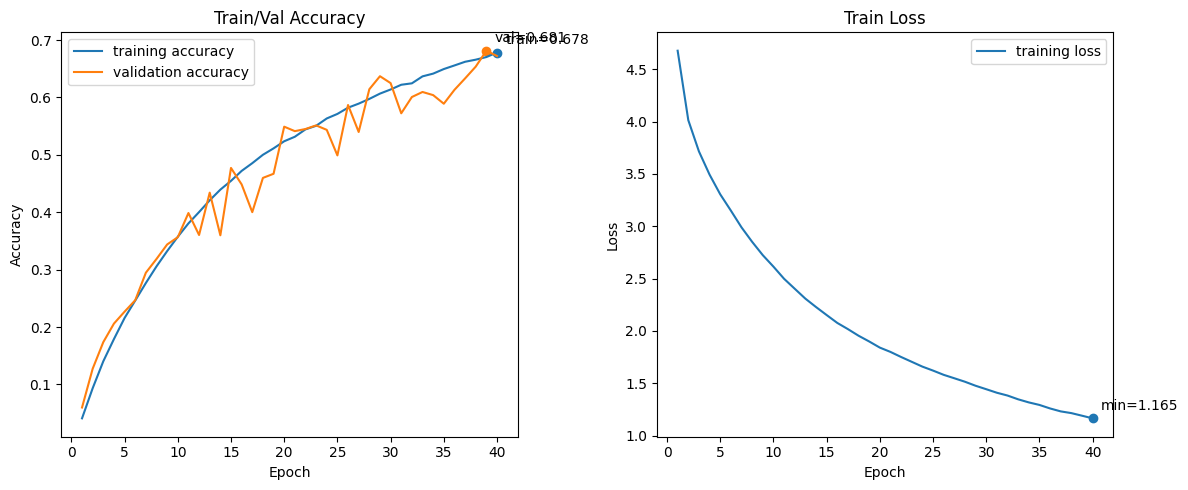

In [44]:
train_acc, loss, val_acc = train(
    model,
    epoch=40,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler_base,
    val_loader=val_loader,
 )

plot_metrics(train_acc, val_acc, loss)

In [45]:
def test(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="测试中"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    print(f"测试准确率: {accuracy:.4f}")

In [46]:
test_dataset = DataSetLoader_test(root_dir=test_dir, num_classes=101, transform=transform_val)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=8)
test(model, test_loader, device)

测试中: 100%|██████████| 395/395 [02:04<00:00,  3.17it/s]

测试准确率: 0.5554


In [47]:
save_checkpoint(
    path="densenet201_food101_cheat_40.pth",
    model=model,
    optimizer=optimizer,
    scheduler=scheduler_base,
    epoch=40,
    best_acc=max(val_acc),
)

Saved checkpoint to densenet201_food101_cheat_40.pth


In [49]:
train_acc1, loss1, val_acc1 = train(
    model,
    epoch=40,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler_base,
    val_loader=val_loader,
 )



验证中: 100%|██████████| 119/119 [00:39<00:00,  3.02it/s]


Epoch [1/40] 平均损失: 1.1376 训练准确率: 0.6848 验证准确率: 0.6296


验证中: 100%|██████████| 119/119 [00:40<00:00,  2.97it/s]


Epoch [2/40] 平均损失: 1.0989 训练准确率: 0.6922 验证准确率: 0.6866


验证中: 100%|██████████| 119/119 [00:39<00:00,  3.03it/s]


...

Epoch [38/40] 平均损失: 0.6898 训练准确率: 0.7955 验证准确率: 0.7696


验证中: 100%|██████████| 119/119 [00:40<00:00,  2.91it/s]


Epoch [39/40] 平均损失: 0.6852 训练准确率: 0.7977 验证准确率: 0.7104


验证中: 100%|██████████| 119/119 [00:39<00:00,  3.02it/s]

Epoch [40/40] 平均损失: 0.6686 训练准确率: 0.8016 验证准确率: 0.7769


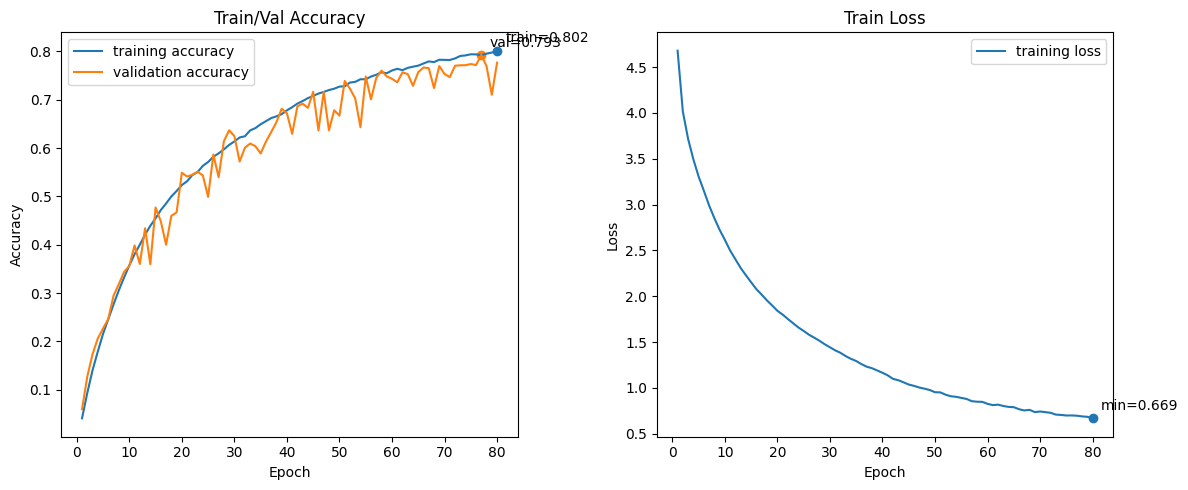

In [50]:
plot_metrics(train_acc+train_acc1, val_acc+val_acc1, loss+loss1)

In [51]:
save_checkpoint(
    path="densenet201_food101_cheat_80.pth",
    model=model,
    optimizer=optimizer,
    scheduler=scheduler_base,
    epoch=100,
    best_acc=max(val_acc1 + val_acc) if val_acc1 else max(val_acc),
)

Saved checkpoint to densenet201_food101_cheat_80.pth


In [52]:
test(model, test_loader, device)

测试中: 100%|██████████| 395/395 [02:08<00:00,  3.07it/s]

测试准确率: 0.5698
